In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn missingno


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\Gunjan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brandao/diabetes")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Gunjan\.cache\kagglehub\datasets\brandao\diabetes\versions\1


In [4]:
import shutil
import os

source = path
destination = r"C:\Users\Gunjan\OneDrive\Desktop\hospital-readmission\data"

shutil.copytree(source, destination, dirs_exist_ok=True)

'C:\\Users\\Gunjan\\OneDrive\\Desktop\\hospital-readmission\\data'

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import warnings

from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [6]:
df = pd.read_csv('../data/diabetic_data.csv')

print(f'📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'📋 Columns: {list(df.columns)}')

📊 Dataset Shape: 101,766 rows × 50 columns
📋 Columns: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  in

In [9]:
print('Statistical Summary:')
df.describe().round(2)

Statistical Summary:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.652016e+08,5.433040e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.026403e+08,3.869636e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.252200e+04,1.350000e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.496119e+07,2.341322e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.523890e+08,4.550514e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.302709e+08,8.754595e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.438672e+08,1.895026e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


## Handle Missing Values

In [10]:
df.replace('?', np.nan, inplace=True)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print('Columns with Missing Values:')
print(missing_df.to_string())

Columns with Missing Values:
                   Missing Count  Missing %
weight                     98569      96.86
max_glu_serum              96420      94.75
A1Cresult                  84748      83.28
medical_specialty          49949      49.08
payer_code                 40256      39.56
race                        2273       2.23
diag_3                      1423       1.40
diag_2                       358       0.35
diag_1                        21       0.02


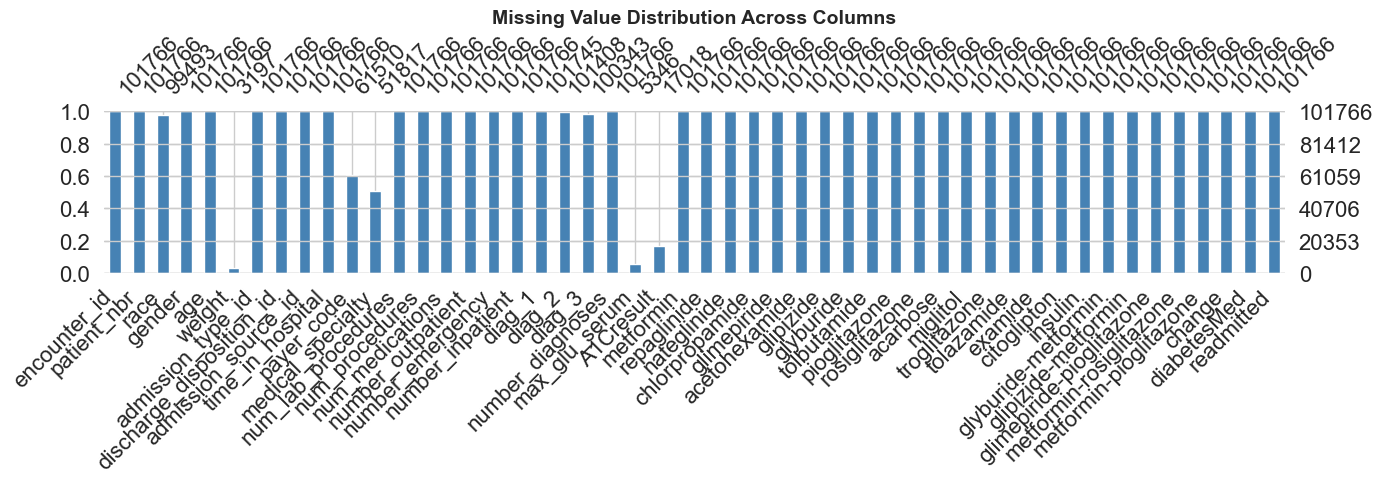

 Chart saved as missing_values.png


In [11]:
plt.figure(figsize=(14, 5))
msno.bar(df, color='steelblue', figsize=(14, 5))
plt.title('Missing Value Distribution Across Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputImg/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart saved as missing_values.png')

In [12]:
threshold = 40
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()
print(f'🗑️  Dropping columns with >{threshold}% missing: {cols_to_drop}')
df.drop(columns=cols_to_drop, inplace=True)

# Also drop columns that are identifiers (not useful for prediction)
id_cols = ['encounter_id', 'patient_nbr']
df.drop(columns=[c for c in id_cols if c in df.columns], inplace=True)
print(f' Dropped identifier columns: {id_cols}')

print(f'\nDataset shape after dropping: {df.shape}')

🗑️  Dropping columns with >40% missing: ['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']
 Dropped identifier columns: ['encounter_id', 'patient_nbr']

Dataset shape after dropping: (101766, 44)


In [13]:
cat_cols_with_missing = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()
]
for col in cat_cols_with_missing:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  Filled "{col}" missing values with mode: "{mode_val}"')

# Numerical columns → fill with median
num_cols_with_missing = df.select_dtypes(include='number').columns[
    df.select_dtypes(include='number').isnull().any()
]
for col in num_cols_with_missing:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  Filled "{col}" missing values with median: {median_val}')

print(f'\nTotal missing values remaining: {df.isnull().sum().sum()}')

  Filled "race" missing values with mode: "Caucasian"
  Filled "payer_code" missing values with mode: "MC"
  Filled "diag_1" missing values with mode: "428"
  Filled "diag_2" missing values with mode: "276"
  Filled "diag_3" missing values with mode: "250"

Total missing values remaining: 0


In [14]:
before = len(df)

if 'patient_nbr' in df.columns:
    df = df.sort_index().drop_duplicates(subset='patient_nbr', keep='first')
    print(f'👤 Removed {before - len(df):,} duplicate patient encounters')
else:
    print('patient_nbr column already removed — skipping deduplication')

print(f' Dataset shape: {df.shape}')

patient_nbr column already removed — skipping deduplication
 Dataset shape: (101766, 44)


In [15]:
def map_icd9_to_category(code):
    """Map ICD-9 diagnosis code to a readable disease category."""
    try:
        code = str(code).strip()
        if code.startswith('V') or code.startswith('E'):
            return 'Other'
        code_num = float(code)
        if 390 <= code_num <= 459 or code_num == 785:
            return 'Circulatory'
        elif 460 <= code_num <= 519 or code_num == 786:
            return 'Respiratory'
        elif 520 <= code_num <= 579 or code_num == 787:
            return 'Digestive'
        elif code_num == 250:
            return 'Diabetes'
        elif 800 <= code_num <= 999:
            return 'Injury'
        elif 710 <= code_num <= 739:
            return 'Musculoskeletal'
        elif 580 <= code_num <= 629 or code_num == 788:
            return 'Genitourinary'
        elif 140 <= code_num <= 239:
            return 'Neoplasms'
        else:
            return 'Other'
    except:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    if col in df.columns:
        df[col] = df[col].apply(map_icd9_to_category)
        print(f' Mapped {col}: {df[col].value_counts().to_dict()}')

 Mapped diag_1: {'Circulatory': 30458, 'Other': 26694, 'Respiratory': 14423, 'Digestive': 9475, 'Injury': 6974, 'Genitourinary': 5117, 'Musculoskeletal': 4957, 'Neoplasms': 3433, 'Diabetes': 235}
 Mapped diag_2: {'Other': 33634, 'Circulatory': 31881, 'Respiratory': 10895, 'Genitourinary': 8376, 'Diabetes': 6071, 'Digestive': 4170, 'Neoplasms': 2547, 'Injury': 2428, 'Musculoskeletal': 1764}
 Mapped diag_3: {'Other': 34797, 'Circulatory': 30306, 'Diabetes': 12978, 'Respiratory': 7358, 'Genitourinary': 6680, 'Digestive': 3930, 'Injury': 1946, 'Musculoskeletal': 1915, 'Neoplasms': 1856}


In [16]:
print('Original readmission distribution:')
print(df['readmitted'].value_counts())

df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('\n New binary target (readmitted_30):')
print(df['readmitted_30'].value_counts())
print(f'  Readmitted (<30 days): {df["readmitted_30"].sum():,} ({df["readmitted_30"].mean()*100:.1f}%)')
print(f'  Not readmitted:        {(df["readmitted_30"]==0).sum():,} ({(1-df["readmitted_30"].mean())*100:.1f}%)')

Original readmission distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

 New binary target (readmitted_30):
readmitted_30
0    90409
1    11357
Name: count, dtype: int64
  Readmitted (<30 days): 11,357 (11.2%)
  Not readmitted:        90,409 (88.8%)


In [17]:
df.drop(columns=['readmitted'], inplace=True)
print('  Dropped original readmitted column')

  Dropped original readmitted column


In [18]:
# Identify categorical columns (excluding target)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f' Categorical columns to encode ({len(cat_cols)}): {cat_cols}')

# Apply Label Encoding to each
le = LabelEncoder()
label_encoders = {}

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print(f'Dataset shape: {df.shape}')
df.head(3)

 Categorical columns to encode (32): ['race', 'gender', 'age', 'payer_code', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Dataset shape: (101766, 44)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,num_lab_procedures,num_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,2,0,0,6,25,1,1,7,41,0,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,7,59,0,...,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,7,11,5,...,0,1,1,0,0,0,0,1,1,0


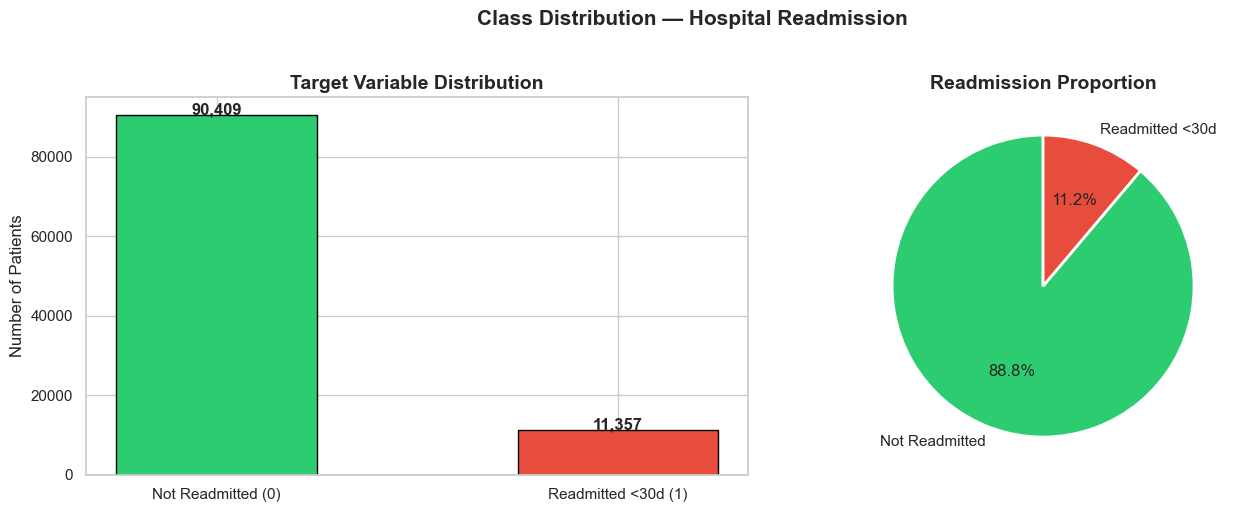

Saved: chart1_class_distribution.png


In [19]:
# ----- CHART 1: Target Variable Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['readmitted_30'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Not Readmitted (0)', 'Readmitted <30d (1)'], counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted <30d'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Readmission Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution — Hospital Readmission', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputImg/chart1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart1_class_distribution.png')

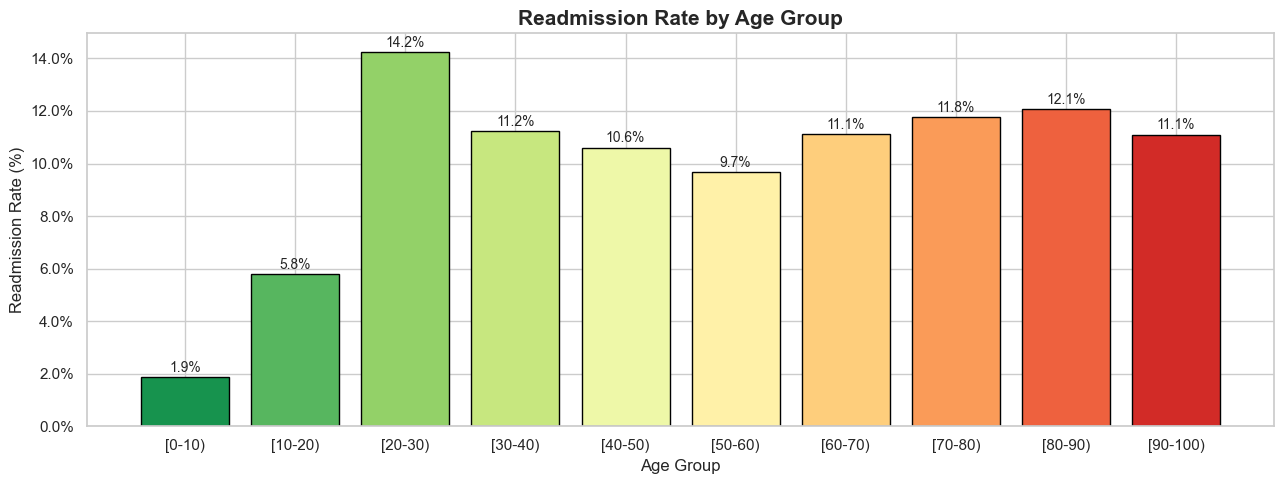

Saved: chart2_readmission_by_age.png


In [20]:
# ----- CHART 2: Readmission Rate by Age Group -----

# Decode age column for readability
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
             '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

# Reload original before encoding for this chart
df_raw_age = pd.read_csv('../data/diabetic_data.csv')
df_raw_age.replace('?', np.nan, inplace=True)
df_raw_age['readmitted_30'] = (df_raw_age['readmitted'] == '<30').astype(int)

age_readmit = df_raw_age.groupby('age')['readmitted_30'].mean() * 100
age_readmit = age_readmit.reindex([a for a in age_order if a in age_readmit.index])

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(age_readmit.index, age_readmit.values,
              color=sns.color_palette('RdYlGn_r', len(age_readmit)), edgecolor='black')
ax.set_title('Readmission Rate by Age Group', fontsize=15, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Readmission Rate (%)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2, f'{h:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputImg/chart2_readmission_by_age.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart2_readmission_by_age.png')

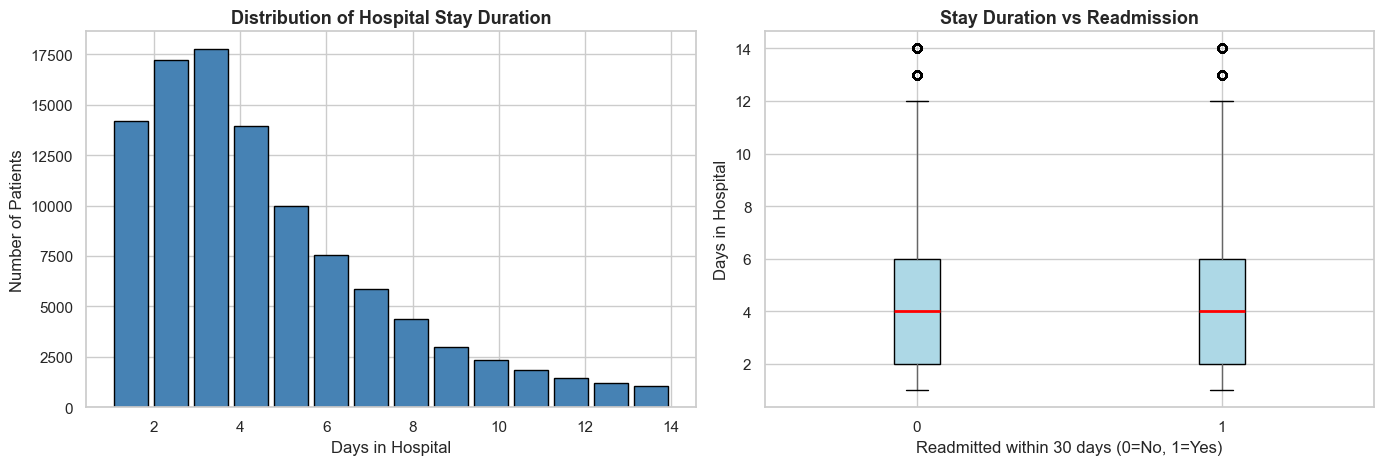

Saved: chart3_stay_duration.png


In [21]:
# ----- CHART 3: Time in Hospital Distribution -----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['time_in_hospital'], bins=14, color='steelblue', edgecolor='black', rwidth=0.85)
axes[0].set_title('Distribution of Hospital Stay Duration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Days in Hospital')
axes[0].set_ylabel('Number of Patients')

# Box plot by readmission
df.boxplot(column='time_in_hospital', by='readmitted_30', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Stay Duration vs Readmission', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Readmitted within 30 days (0=No, 1=Yes)')
axes[1].set_ylabel('Days in Hospital')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputImg/chart3_stay_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart3_stay_duration.png')

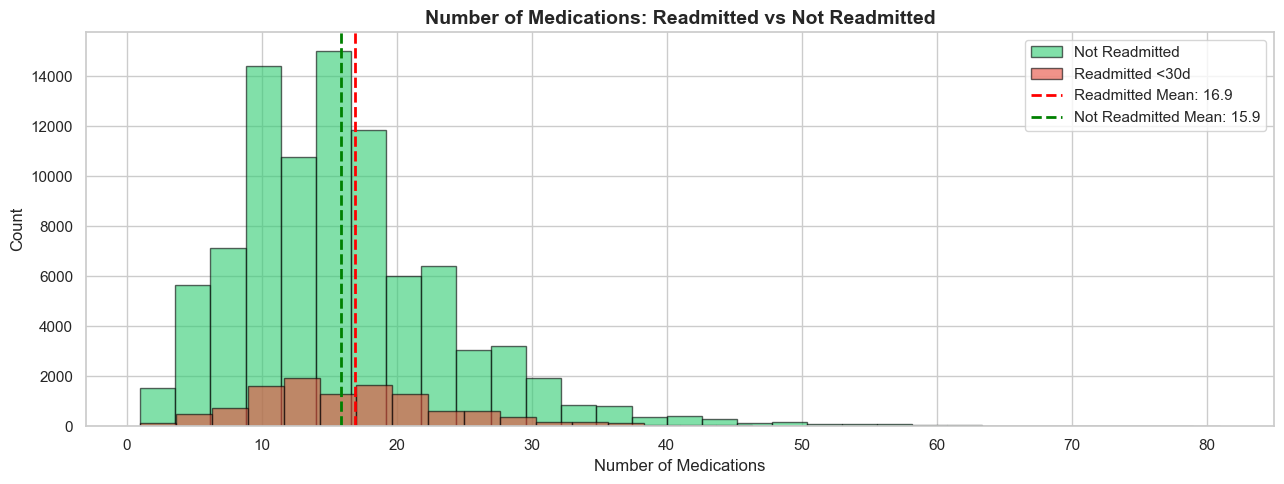

Saved: chart4_medications.png


In [22]:
# ----- CHART 4: Number of Medications vs Readmission -----
fig, ax = plt.subplots(figsize=(13, 5))

readmitted_meds = df[df['readmitted_30'] == 1]['num_medications']
not_readmitted_meds = df[df['readmitted_30'] == 0]['num_medications']

ax.hist(not_readmitted_meds, bins=30, alpha=0.6, label='Not Readmitted', color='#2ecc71', edgecolor='black')
ax.hist(readmitted_meds, bins=30, alpha=0.6, label='Readmitted <30d', color='#e74c3c', edgecolor='black')
ax.axvline(readmitted_meds.mean(), color='red', linestyle='--', linewidth=2, label=f'Readmitted Mean: {readmitted_meds.mean():.1f}')
ax.axvline(not_readmitted_meds.mean(), color='green', linestyle='--', linewidth=2, label=f'Not Readmitted Mean: {not_readmitted_meds.mean():.1f}')
ax.set_title('Number of Medications: Readmitted vs Not Readmitted', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Medications')
ax.set_ylabel('Count')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../outputImg/chart4_medications.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart4_medications.png')

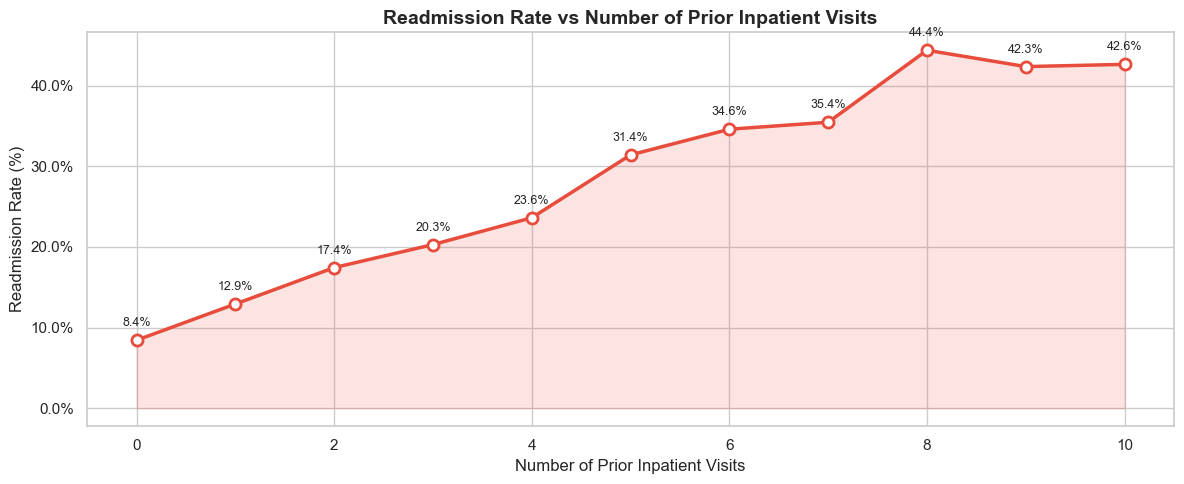

Saved: chart5_prior_visits.png


In [23]:
# ----- CHART 5: Number of Prior Inpatient Visits vs Readmission -----
prior_readmit = df.groupby('number_inpatient')['readmitted_30'].mean() * 100
prior_readmit = prior_readmit[prior_readmit.index <= 10]  # Cap at 10 for clarity

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prior_readmit.index, prior_readmit.values, marker='o', linewidth=2.5,
        color='#e74c3c', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(prior_readmit.index, prior_readmit.values, alpha=0.15, color='#e74c3c')
ax.set_title('Readmission Rate vs Number of Prior Inpatient Visits', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Prior Inpatient Visits')
ax.set_ylabel('Readmission Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for x, y in zip(prior_readmit.index, prior_readmit.values):
    ax.annotate(f'{y:.1f}%', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputImg/chart5_prior_visits.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart5_prior_visits.png')

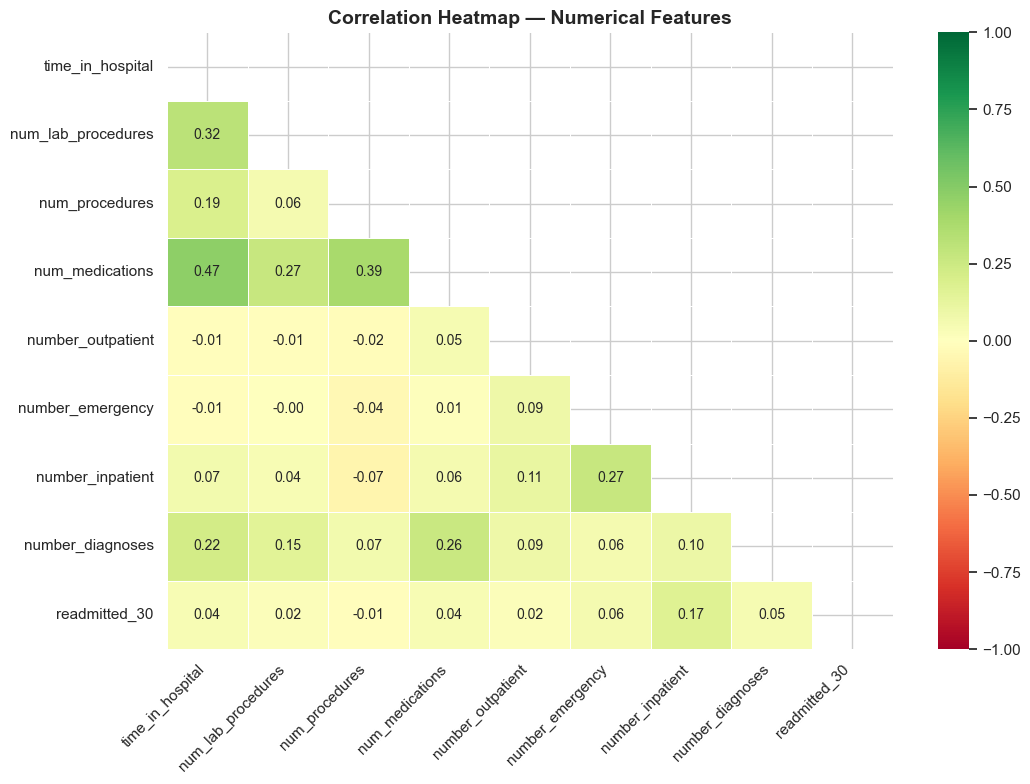

Saved: chart6_correlation_heatmap.png


In [24]:
# ----- CHART 6: Correlation Heatmap -----
numerical_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
                  'num_medications', 'number_outpatient', 'number_emergency',
                  'number_inpatient', 'number_diagnoses', 'readmitted_30']

corr_cols = [c for c in numerical_cols if c in df.columns]
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../outputImg/chart6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart6_correlation_heatmap.png')

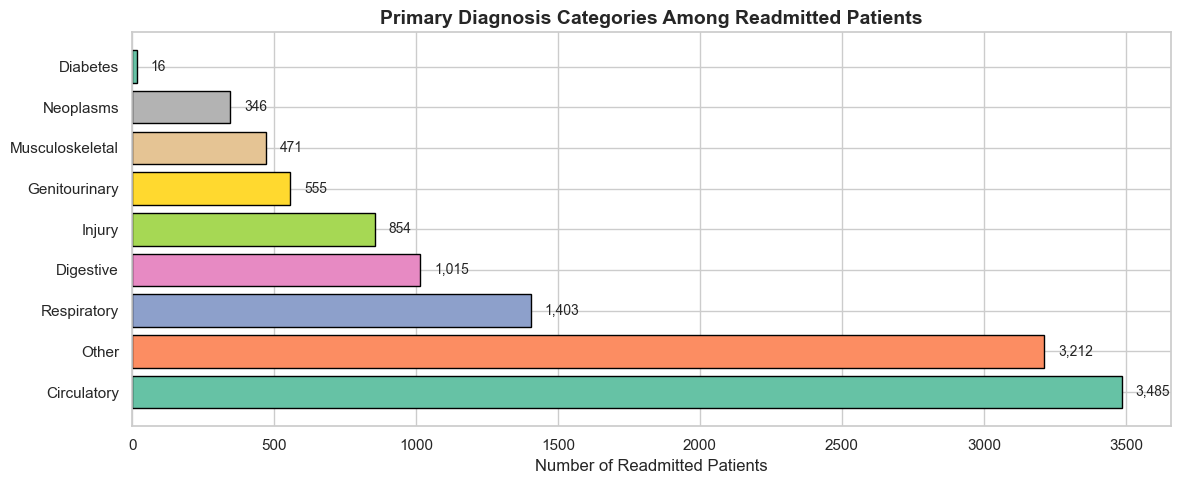

Saved: chart7_top_diagnoses.png


In [25]:
# ----- CHART 7: Top Diagnoses Among Readmitted Patients -----
if 'diag_1' in df.columns:
    # Reload with mapped categories for clarity
    df_raw2 = pd.read_csv('../data/diabetic_data.csv')
    df_raw2.replace('?', np.nan, inplace=True)
    df_raw2['readmitted_30'] = (df_raw2['readmitted'] == '<30').astype(int)
    df_raw2['diag_1_cat'] = df_raw2['diag_1'].apply(map_icd9_to_category)

    diag_readmit = df_raw2[df_raw2['readmitted_30'] == 1]['diag_1_cat'].value_counts()

    fig, ax = plt.subplots(figsize=(12, 5))
    colors_diag = sns.color_palette('Set2', len(diag_readmit))
    bars = ax.barh(diag_readmit.index, diag_readmit.values, color=colors_diag, edgecolor='black')
    ax.set_title('Primary Diagnosis Categories Among Readmitted Patients', fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Readmitted Patients')
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 50, bar.get_y() + bar.get_height()/2, f'{int(w):,}', va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig('../outputImg/chart7_top_diagnoses.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: chart7_top_diagnoses.png')

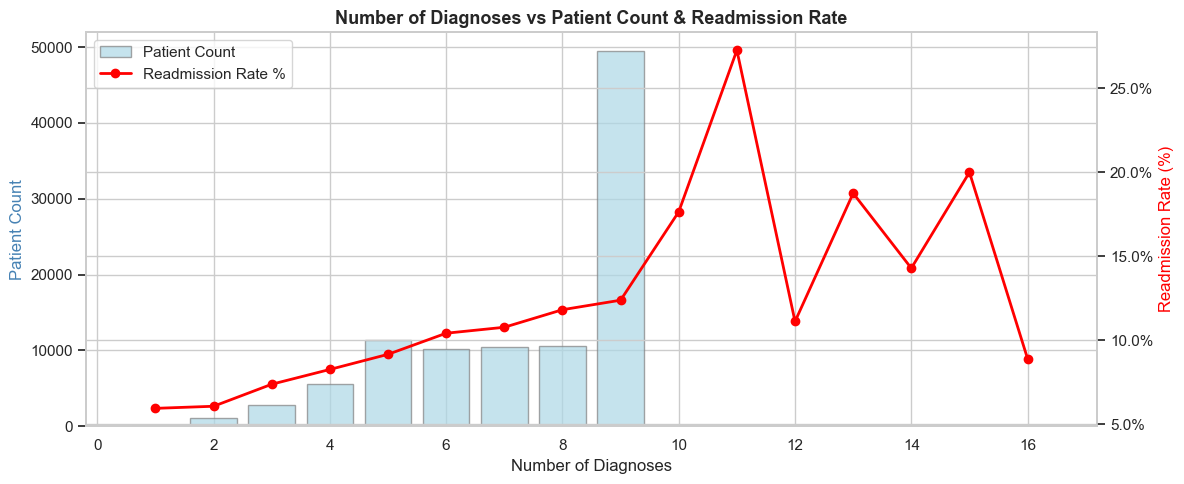

Saved: chart8_num_diagnoses.png


In [26]:
# ----- CHART 8: Number of Diagnoses Distribution -----
fig, ax = plt.subplots(figsize=(12, 5))

diag_counts = df.groupby('number_diagnoses')['readmitted_30'].agg(['mean', 'count']).reset_index()
diag_counts['mean'] *= 100

ax2 = ax.twinx()
ax.bar(diag_counts['number_diagnoses'], diag_counts['count'],
       color='lightblue', edgecolor='gray', alpha=0.7, label='Patient Count')
ax2.plot(diag_counts['number_diagnoses'], diag_counts['mean'],
         color='red', marker='o', linewidth=2, markersize=6, label='Readmission Rate %')

ax.set_title('Number of Diagnoses vs Patient Count & Readmission Rate', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Diagnoses')
ax.set_ylabel('Patient Count', color='steelblue')
ax2.set_ylabel('Readmission Rate (%)', color='red')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../outputImg/chart8_num_diagnoses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart8_num_diagnoses.png')

In [27]:
print('=' * 60)
print('EDA KEY FINDINGS SUMMARY')
print('=' * 60)
print(f'\n Dataset: {df.shape[0]:,} patients × {df.shape[1]} features')
print(f'\n Target variable (readmitted_30):')
print(f'   Readmitted (<30 days): {df["readmitted_30"].sum():,} ({df["readmitted_30"].mean()*100:.1f}%)')
print(f'   Not readmitted:        {(df["readmitted_30"]==0).sum():,} ({(1-df["readmitted_30"].mean())*100:.1f}%)')
print(f'\n Class imbalance detected — SMOTE will be applied in Notebook 2')
print(f'\n Avg medications (readmitted):     {df[df["readmitted_30"]==1]["num_medications"].mean():.1f}')
print(f'   Avg medications (not readmitted): {df[df["readmitted_30"]==0]["num_medications"].mean():.1f}')
print(f'\n Avg stay (readmitted):     {df[df["readmitted_30"]==1]["time_in_hospital"].mean():.1f} days')
print(f'   Avg stay (not readmitted): {df[df["readmitted_30"]==0]["time_in_hospital"].mean():.1f} days')
print(f'\n Avg prior visits (readmitted):     {df[df["readmitted_30"]==1]["number_inpatient"].mean():.1f}')
print(f'   Avg prior visits (not readmitted): {df[df["readmitted_30"]==0]["number_inpatient"].mean():.1f}')
print('\n' + '=' * 60)

EDA KEY FINDINGS SUMMARY

 Dataset: 101,766 patients × 44 features

 Target variable (readmitted_30):
   Readmitted (<30 days): 11,357 (11.2%)
   Not readmitted:        90,409 (88.8%)

 Class imbalance detected — SMOTE will be applied in Notebook 2

 Avg medications (readmitted):     16.9
   Avg medications (not readmitted): 15.9

 Avg stay (readmitted):     4.8 days
   Avg stay (not readmitted): 4.3 days

 Avg prior visits (readmitted):     1.2
   Avg prior visits (not readmitted): 0.6



In [28]:
output_path = '../data/cleaned_data.csv'
df.to_csv(output_path, index=False)

In [29]:
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

   Shape: 101,766 rows × 44 columns
